<a href="https://colab.research.google.com/github/Aswinij28/Machine-Learning-and-Data-visualisation/blob/main/Alumni_Tracking_and_Engagement_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Success Metrics Comparison Validation ---
Success Evaluation: Arun outperforms Deepa based on corporate index.


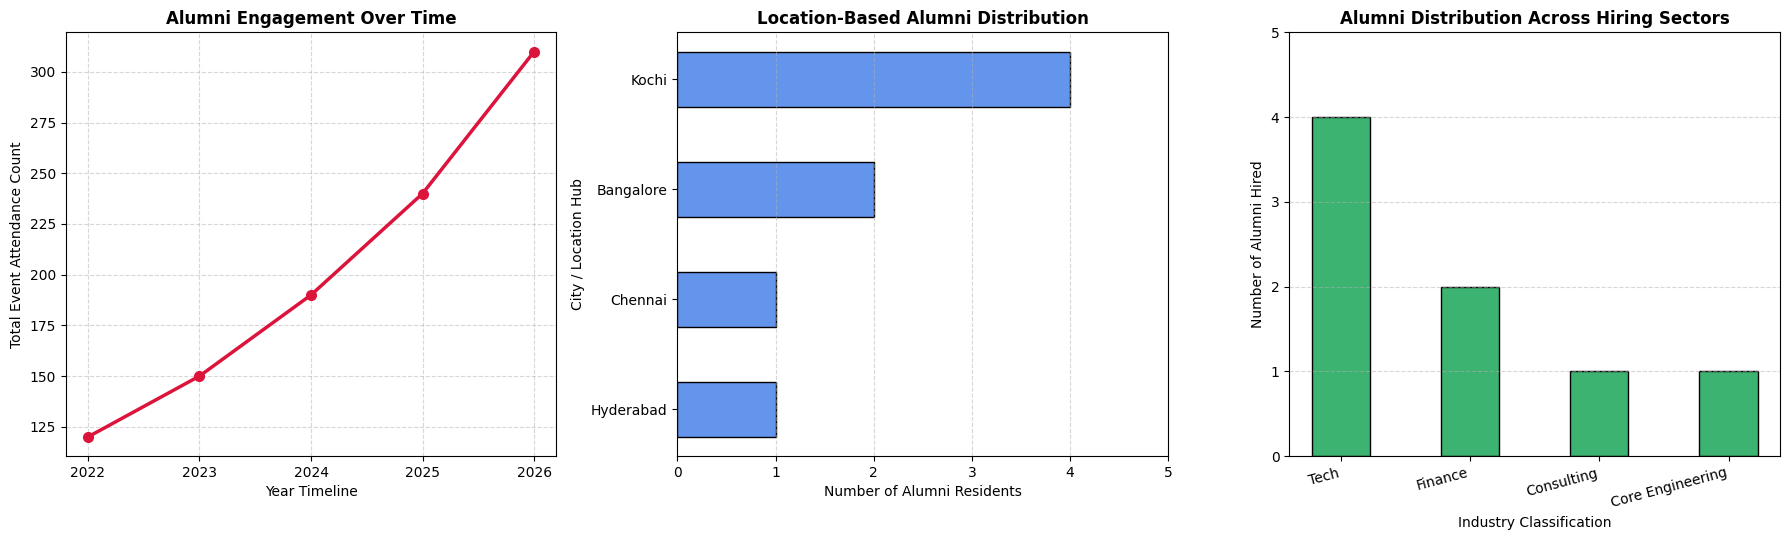

In [1]:
import matplotlib.pyplot as plt

class Employer:
    """Class representing an Alumni's Employer."""
    def __init__(self, name, sector, location):
        self.name = name
        self.sector = sector
        self.location = location

class Batch:
    """Class representing a Graduation Batch year."""
    def __init__(self, year):
        self.year = year


class Alumni:
    """Class representing an individual Alumnus/Alumna."""
    def __init__(self, name, batch, employer, salary, performance_rating):
        self.name = name
        self.batch = batch
        self.employer = employer
        self.salary = salary
        self.performance_rating = performance_rating

    def get_success_score(self):
        """Calculates a composite success score based on salary and rating."""

        return (self.salary / 10000) + (self.performance_rating * 10)


    def __gt__(self, other):
        """Greater-than comparison operator (>)."""
        return self.get_success_score() > other.get_success_score()

    def __lt__(self, other):
        """Less-than comparison operator (<)."""
        return self.get_success_score() < other.get_success_score()

    def __eq__(self, other):
        """Equality comparison operator (==)."""
        return self.get_success_score() == other.get_success_score()


class EngagementRecord:
    """Class tracking engagement/attendance counts over the years."""
    def __init__(self, year, activity_type, attendance_count):
        self.year = year
        self.activity_type = activity_type
        self.attendance_count = attendance_count




b2022 = Batch(2022)
b2023 = Batch(2023)
b2024 = Batch(2024)


emp1 = Employer("Google", "Tech", "Bangalore")
emp2 = Employer("TCS", "Tech", "Kochi")
emp3 = Employer("Deloitte", "Consulting", "Hyderabad")
emp4 = Employer("Federal Bank", "Finance", "Kochi")
emp5 = Employer("BMW", "Core Engineering", "Chennai")


alumni_list = [
    Alumni("Arun", b2022, emp1, 1500000, 4.5),
    Alumni("Deepa", b2022, emp2, 500000, 4.0),
    Alumni("Rahul", b2023, emp3, 800000, 4.2),
    Alumni("Meera", b2023, emp4, 700000, 4.8),
    Alumni("Kiran", b2024, emp5, 900000, 3.9),
    Alumni("Sanjana", b2024, emp1, 1300000, 4.6),
    Alumni("Vivek", b2022, emp4, 750000, 4.1),
    Alumni("Anjali", b2023, emp2, 450000, 4.3),
]


engagement_history = [
    EngagementRecord(2022, "Alumni Meet", 120),
    EngagementRecord(2023, "Alumni Meet", 150),
    EngagementRecord(2024, "Alumni Meet", 190),
    EngagementRecord(2025, "Alumni Meet", 240),
    EngagementRecord(2026, "Alumni Meet", 310),
]





years_eng = [record.year for record in engagement_history]
counts_eng = [record.attendance_count for record in engagement_history]


location_counts = {}
for al in alumni_list:
    loc = al.employer.location
    location_counts[loc] = location_counts.get(loc, 0) + 1


sorted_locations = sorted(location_counts.items(), key=lambda x: x[1], reverse=False)
locations = [x[0] for x in sorted_locations]
loc_values = [x[1] for x in sorted_locations]


sector_counts = {}
for al in alumni_list:
    sec = al.employer.sector
    sector_counts[sec] = sector_counts.get(sec, 0) + 1


sorted_sectors = sorted(sector_counts.items(), key=lambda x: x[1], reverse=True)
sectors = [x[0] for x in sorted_sectors]
sec_values = [x[1] for x in sorted_sectors]




fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))


axs[0].plot(years_eng, counts_eng, marker='o', color='crimson', linestyle='-', linewidth=2.5, markersize=7)
axs[0].set_title("Alumni Engagement Over Time", fontsize=12, fontweight='bold')
axs[0].set_xlabel("Year Timeline", fontsize=10)
axs[0].set_ylabel("Total Event Attendance Count", fontsize=10)
axs[0].set_xticks(years_eng)
axs[0].grid(True, linestyle='--', alpha=0.5)


axs[1].barh(locations, loc_values, color='cornflowerblue', edgecolor='black', height=0.5)
axs[1].set_title("Location-Based Alumni Distribution", fontsize=12, fontweight='bold')
axs[1].set_xlabel("Number of Alumni Residents", fontsize=10)
axs[1].set_ylabel("City / Location Hub", fontsize=10)
axs[1].set_xticks(range(0, max(loc_values) + 2))
axs[1].grid(axis='x', linestyle='--', alpha=0.5)

axs[2].bar(sectors, sec_values, color='mediumseagreen', edgecolor='black', width=0.45)
axs[2].set_title("Alumni Distribution Across Hiring Sectors", fontsize=12, fontweight='bold')
axs[2].set_xlabel("Industry Classification", fontsize=10)
axs[2].set_ylabel("Number of Alumni Hired", fontsize=10)
axs[2].set_yticks(range(0, max(sec_values) + 2))
axs[2].grid(axis='y', linestyle='--', alpha=0.5)


plt.setp(axs[2].get_xticklabels(), rotation=15, ha="right")


plt.tight_layout()
plt.savefig("alumni_engagement_analytics.png", dpi=300)


print("--- Success Metrics Comparison Validation ---")
if alumni_list[0] > alumni_list[1]:
    print(f"Success Evaluation: {alumni_list[0].name} outperforms {alumni_list[1].name} based on corporate index.")